In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 5)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
EPOCHS = 20


In [28]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

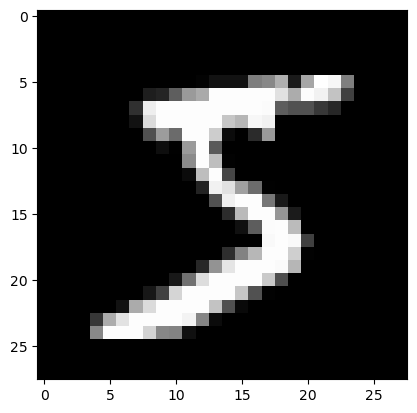

In [29]:
plt.imshow(x_train[0], cmap='gray')

In [30]:
x_train[0].shape

(28, 28)

In [31]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

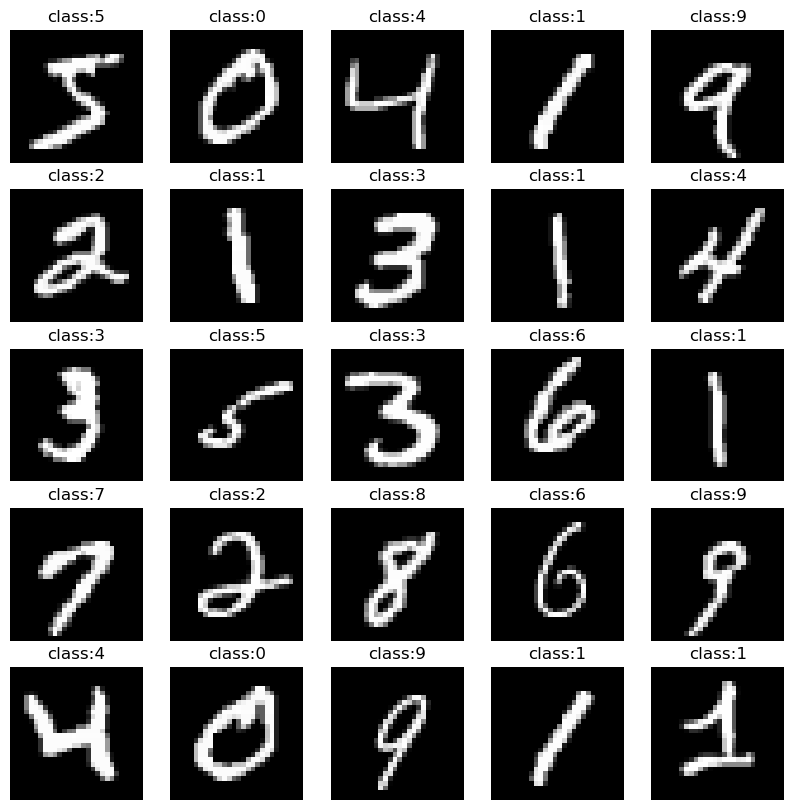

In [32]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis('off')
    plt.title("class:"+str(y_train[i]))

In [33]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [34]:
x_train.shape

(60000, 28, 28)

In [35]:
x_val = x_train[50000:]
y_val = y_train[50000:]

x_train = x_train[:50000]
y_train = y_train[:50000]

In [36]:
print(x_val.shape, x_train.shape)

(10000, 28, 28) (50000, 28, 28)


In [37]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [38]:
history= model.fit(x_train, y_train, epochs = EPOCHS, validation_data=(x_val, y_val), callbacks = [es])
hist = pd.DataFrame(history.history)

Epoch 1/20
1563/1563 [==============================] - 7s 4ms/step - loss: 0.2866 - accuracy: 0.9175 - val_loss: 0.1645 - val_accuracy: 0.9534
Epoch 2/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1286 - accuracy: 0.9618 - val_loss: 0.1090 - val_accuracy: 0.9680
Epoch 3/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0881 - accuracy: 0.9734 - val_loss: 0.1028 - val_accuracy: 0.9689
Epoch 4/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0665 - accuracy: 0.9800 - val_loss: 0.0836 - val_accuracy: 0.9760
Epoch 5/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0502 - accuracy: 0.9846 - val_loss: 0.0814 - val_accuracy: 0.9767
Epoch 6/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0396 - accuracy: 0.9874 - val_loss: 0.0840 - val_accuracy: 0.9759
Epoch 7/20
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0316 - accuracy: 0.9904 - val_loss: 0.0815 - val_accuracy:

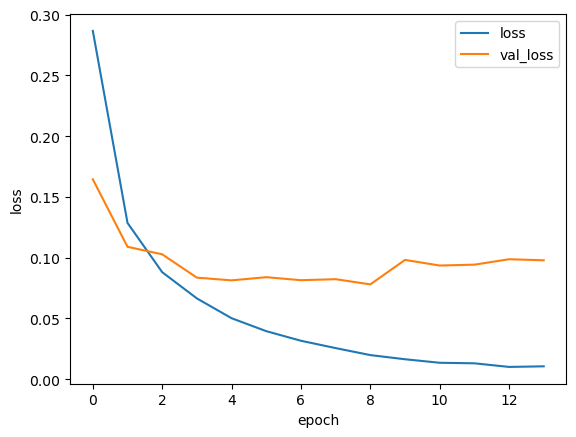

In [39]:
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [40]:
output = model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.0831 - accuracy: 0.9794


In [41]:
y_pred = model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


[7.2244064e-12 3.1555298e-13 3.1482861e-09 4.1162239e-05 3.6875712e-20
 3.8432570e-11 1.2924751e-21 9.9995881e-01 1.2061269e-09 4.9891238e-08]


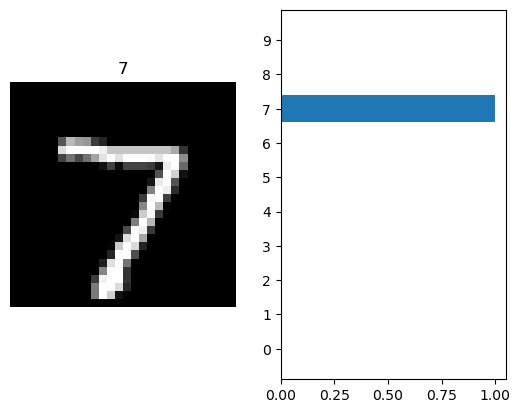

In [42]:
plt.subplot(1,2,1)
plt.imshow(x_test[0], cmap="gray")
plt.axis('off')
plt.title(y_test[0])

plt.subplot(1,2,2)
plt.barh(np.arange(10), y_pred[0])
plt.yticks(np.arange(10))
print(y_pred[0])

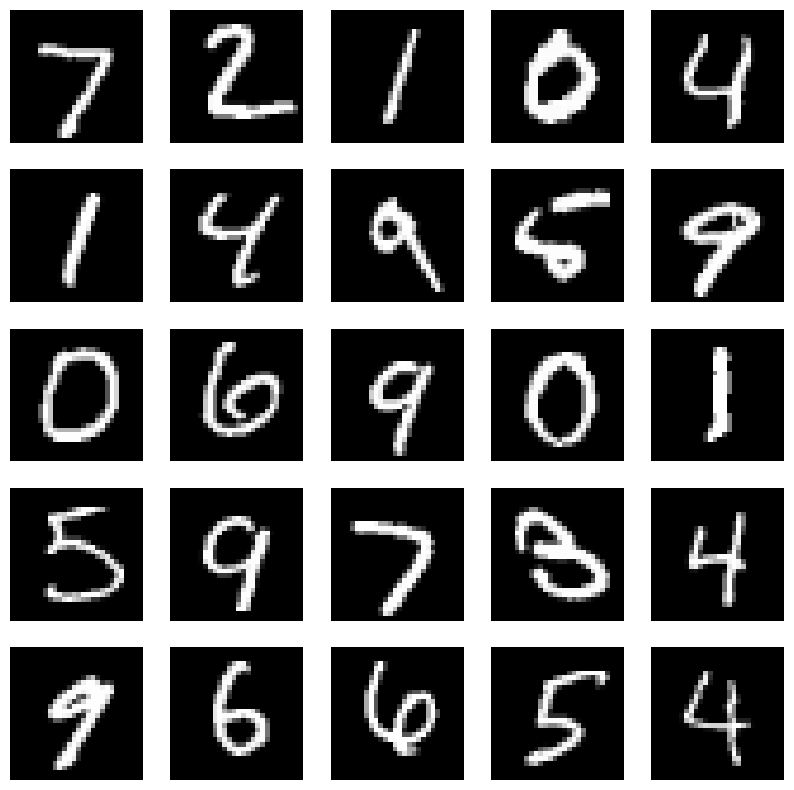

In [43]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')

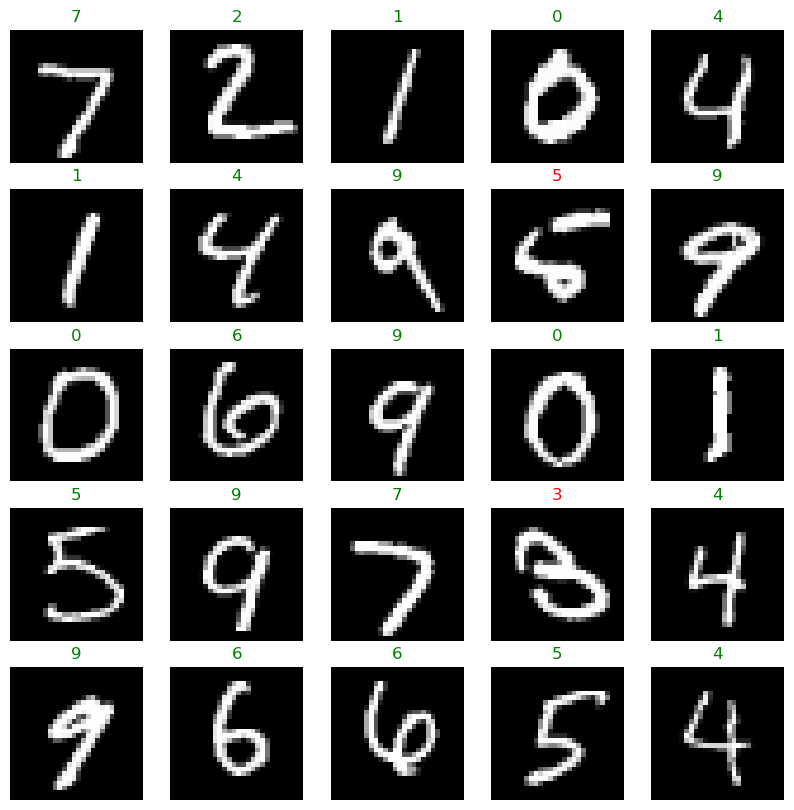

In [44]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    if np.argmax(y_pred[i]) == y_test[i]:
        plt.title(y_test[i], color = 'green')
    else:
        plt.title(y_test[i], color = 'red')